In [1]:
import os
import torch
import torch.nn as nn
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
import torch.nn.functional as F
import torch.optim as optim
import random
import matplotlib.pyplot as plt

cwd = Path(os.getcwd())
images_lib = cwd / "data" / "images" / "Images"
annotations_lib = cwd / "data" / "Annotation"

dtype = torch.float
device = torch.device("cuda:0")

In [2]:
# get all the labels

classes = []
for directory in os.listdir(annotations_lib):
#     classes += [directory[10:]]
    if 'Chihuahua' in directory or 'pug' in directory:
        classes += [directory[10:]]


In [3]:
class ConvNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer6 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=3))
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        return out

In [4]:
class labeled_image:
    def __init__(self, image_path, meta_path):
        transform = transforms.Compose(
            [transforms.ToTensor(),
             transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        self.image = Image.open(str(image_path)+".jpg").convert('RGB').resize((100,100))
        self.tensor = transform(self.image)
        self.meta = {node.tag: node.text for node in ET.parse(str(meta_path)).getroot().iter() }
        [self.meta.pop(key, None) for key in dict(self.meta) if '\n' in self.meta[key]]
        global classes
        self.index = self.set_label(classes)
    def set_label(self, classes):
        for index, label in enumerate(classes):
            if self.meta['name'] == label:
                return index
        assert 1==0, 'No label found.'
        
def batch_generator(file_list, batch_size):
    n_total = len(file_list)
    n_images_left= len(file_list)
    n_images_used = 0
    assert n_images_left%batch_size == 0
    shuffled_file_list = random.sample(file_list, len(file_list))
    def _batch_generator():
        nonlocal n_total
        nonlocal n_images_left
        nonlocal n_images_used
        nonlocal batch_size
        nonlocal shuffled_file_list
        if n_images_left == 0:
            return []
        else:
            n_images_left -= batch_size
            return_list = [labeled_image(shuffled_file_list[n][0], shuffled_file_list[n][1]) for n in range(n_images_used, n_images_used+batch_size)]
            n_images_used += batch_size
            return return_list
    return _batch_generator

def list_to_4tensor(tensor_list):
    b = torch.zeros(len(tensor_list), tensor_list[0].shape[0], tensor_list[0].shape[1], tensor_list[0].shape[2], device=device)
    for i in range(b.shape[0]):
        b[i] = tensor_list[i]
    b.requires_grad = True
    return b

In [5]:
batch_size=1
num_classes=120
fc_layer_size = 100

file_list = []
for directory in os.listdir(annotations_lib):
#     for file in os.listdir(annotations_lib / directory):
#         file_list += [(str(images_lib / directory / file), str(annotations_lib / directory / file))]
    if 'Chihuahua' in directory or 'pug' in directory:
        for file in os.listdir(annotations_lib / directory):
            file_list += [(str(images_lib / directory / file), str(annotations_lib / directory / file))]

In [9]:
# net = Net()
net = ConvNet(num_classes=len(classes))
print(classes)
net.cuda()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

['Chihuahua', 'pug']


In [10]:
for epoch in range(100):
    get_batch = batch_generator(file_list, batch_size)
    trainloader = get_batch()
    i=0
    loss_ax = np.zeros(len(file_list))
    while len(trainloader) > 0: 
        optimizer.zero_grad()

        # get the inputs; data is a list of [inputs, labels]
        inputs = list_to_4tensor([data.tensor for data in trainloader])
        labels = torch.cuda.LongTensor([data.index for data in trainloader])
        inputs, labels = inputs.cuda(), labels.cuda()
        # zero the parameter gradients

        # forward + backward + optimize
#         a = list(net.parameters())[0].clone() 
        
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
#         b = list(net.parameters())[0].clone()
#         print("Model updating? ", not(torch.equal(a,b)))

        # print statistics
        loss_ax[i] = loss.item()/batch_size
        if i==0:
            print(epoch, i, loss.item()/batch_size)
        trainloader = get_batch()
        i += 1
    print('Finished Training')

0 0 2.123528003692627
Finished Training
1 0 0.8193868398666382
Finished Training
2 0 0.06430083513259888
Finished Training
3 0 0.3075224757194519
Finished Training
4 0 0.05425402522087097
Finished Training
5 0 0.10316959023475647
Finished Training
6 0 0.0686742439866066
Finished Training
7 0 0.006625115405768156
Finished Training
8 0 0.2815915048122406
Finished Training
9 0 2.88515305519104
Finished Training
10 0 0.003380419919267297
Finished Training
11 0 0.001073499326594174
Finished Training
12 0 0.7433450818061829
Finished Training
13 0 0.0003455280384514481
Finished Training
14 0 0.020260758697986603
Finished Training
15 0 1.2397689715726301e-05
Finished Training
16 0 0.004509399179369211
Finished Training
17 0 0.0018328310688957572
Finished Training
18 0 0.0022170981392264366
Finished Training
19 0 0.006482998840510845
Finished Training
20 0 0.00043478095903992653
Finished Training
21 0 0.0017510809702798724
Finished Training
22 0 0.00539252907037735
Finished Training
23 0 0.0013

tensor([[6.0949e-05, 9.9994e-01]], device='cuda:0', grad_fn=<SoftmaxBackward>)
the dog is a: pug


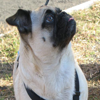

tensor([[3.3367e-04, 9.9967e-01]], device='cuda:0', grad_fn=<SoftmaxBackward>)
the dog is a: pug


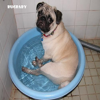

tensor([[9.9979e-01, 2.1249e-04]], device='cuda:0', grad_fn=<SoftmaxBackward>)
the dog is a: Chihuahua


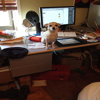

tensor([[9.9968e-01, 3.2313e-04]], device='cuda:0', grad_fn=<SoftmaxBackward>)
the dog is a: Chihuahua


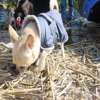

tensor([[1.6919e-05, 9.9998e-01]], device='cuda:0', grad_fn=<SoftmaxBackward>)
the dog is a: pug


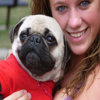

In [65]:
test = batch_generator(file_list, 1)
for n in range(5):
    test_image = test()
    image = test_image[0].image
    test_image = list_to_4tensor([data.tensor for data in test_image])
    net(test_image)
    print(torch.nn.functional.softmax(net(test_image), dim=1))
    print("the dog is a:", chihuahua_or_pug(torch.topk(torch.nn.functional.softmax(net(test_image), dim=1), 1).indices))
    display(image)

In [47]:
def chihuahua_or_pug(n):
    return 'Chihuahua' if n==0 else 'pug'